# E-Commerce Product Delivery Prediction  

### Introduction

In today’s fast-growing e-commerce industry, efficient and timely product delivery plays a crucial role in ensuring customer satisfaction and maintaining competitive advantage. With millions of orders placed online daily, companies face challenges in predicting whether a product will be delivered on time or delayed due to various factors such as location, shipping method, weather conditions, product type, and warehouse handling times.

By leveraging data analytics and machine learning, e-commerce platforms can analyze historical delivery data to identify key patterns that influence delivery success. Predictive models can help businesses forecast delivery outcomes in advance, enabling proactive decisions like route optimization, better inventory management, and enhanced customer communication.

The survey also confirms that late delivery is one of the four major problems faced by e-commerce users.

This project focuses on building a machine learning model to predict whether an e-commerce product will be delivered on time or late, based on several influencing factors extracted from past delivery records.

### Aim of the Project

In today’s fast-growing e-commerce industry, efficient and timely product delivery plays a crucial role in ensuring customer satisfaction and maintaining competitive advantage. With millions of orders placed online daily, companies face challenges in predicting whether a product will be delivered on time or delayed due to various factors such as location, shipping method, weather conditions, product type, and warehouse handling times.

By leveraging data analytics and machine learning, e-commerce platforms can analyze historical delivery data to identify key patterns that influence delivery success. Predictive models can help businesses forecast delivery outcomes in advance, enabling proactive decisions like route optimization, better inventory management, and enhanced customer communication.

This project focuses on building a machine learning model to predict whether an e-commerce product will be delivered on time or late, based on several influencing factors extracted from past delivery records.

### Context
An international e-commerce company based wants to discover key insights from their customer database. They want to use some of the most advanced machine learning techniques to study their customers. The company sells electronic products.

### Dataset Information
The dataset used for building the predictive model contains 10,999 observations and 12 variables. Each record represents a customer order, along with shipment details, customer feedback, and delivery status.


| Variable | Description |
| --- | --- |
|ID|ID Number of Customers|
|Warehouse_block|The Company have big Warehouse which is divided into block such as A,B,C,D,E|
|Mode_of_Shipment|The Company Ships the products in multiple way such as Ship, Flight and Road|
|Customer_care_calls|The number of calls made from enquiry for enquiry of the shipment|
|Customer_rating|The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best)|
|Cost_of_the_Product|Cost of the Product in US Dollars|
|Prior_purchases|The Number of Prior Purchase|
|Product_importance|The company has categorized the product in the various parameter such as low, medium, high|
|Gender|Male and Female|
|Discount_offered|Discount offered on that specific product|
|Weight_in_gms|It is the weight in grams|
|Reached.on.Time_Y.N|It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time|

1. ID - Unique identification number assigned to each customer/order.
2. Warehouse_block - Indicates the warehouse block from which the product was dispatched. The company’s warehouse is divided into blocks — A, B, C, D, and E.
3. Mode_of_shipment - The mode of transportation used to ship the product — Ship, Flight, or Road.
4. Customer_care_calls - Number of calls made by the customer to the company regarding shipment inquiries.
5. Customer_rating - Customer’s satisfaction rating, ranging from 1 (lowest) to 5 (highest).
6. Cost_of_the_product - The cost of the ordered product in US Dollars.
7. Prior_purchases - The number of prior purchases made by the customer.
8. Product_importance - Importance level of the product categorized as Low, Medium, or High.
9. Gender - Gender of the customer (Male or Female).
10. Discount_offered - Discount percentage offered on the specific product.
11. Weight_in_gms - The weight of the product in grams.
12. Reached.on.Time_Y.N - **Target variable** — 1 indicates the product did not reach on time, and 0 indicates the product reached on time.

## Import Libraries

In [5]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Load the dataset

In [7]:
# Loading the dataset
df = pd.read_csv('E_Commerce.csv')

In [8]:
# Display the first few rows of the dataset
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [9]:
# Display last few rows of the dataset
df.tail()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


## Data Preprocessing

1. View the dimensions of the dataset
2. View the data types of the columns
3. Identify numerical and categorical columns
4. Check for duplicate values
5. Handle missing values
6. Descriptive statistical summary of the dataset

#### View the dimensions of the dataset

To understand how many rows (observations) and columns (features) are present.

In [12]:
# Checking the shape (dimensions) of the dataset
df.shape

(10999, 12)

#### View the data types of the columns

To check which columns are numeric, categorical, or object type

In [14]:
# Checking the data types of the column
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [15]:
# Checking basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


#### Identify Numerical and Categorical Columns (Variables)

Helps decide how to handle missing values, encoding, and scaling later.

In [17]:
# Identifying Numerical Variables in the dataset
numerical_vars = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
num_numerical_vars = len(numerical_vars)
print(f"Count of Numerical Variables: {num_numerical_vars}")
print(f"Numerical Variables Features are: {numerical_vars}") 

Count of Numerical Variables: 8
Numerical Variables Features are: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


In [18]:
# Identifying Categorical Variables in the dataset
categorical_vars = [col for col in df.columns if df[col].dtype in ['object']]
num_categorical_vars = len(categorical_vars)
print(f"Count of Categorical Variables: {num_categorical_vars}")
print(f"Categorical Variables Features are: {categorical_vars}")

Count of Categorical Variables: 4
Categorical Variables Features are: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


#### Check for Duplicate Values

Ensures data quality by removing repeated entries that could bias your model.

In [20]:
# Checking for the duplicates values
df.duplicated().sum()

0

#### Handle Missing Values

Identify and impute or drop missing data to maintain consistency.

In [22]:
# Checking missing values in the dataset
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [23]:
# Dropping 'ID' Column - Unnecessary
df.drop(['ID'], axis = 1, inplace = True)

In [24]:
# View the datset after dropping ID column
df.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


#### Descriptive Statistical Summary of the Dataset

Helps understand the distribution, mean, median, outliers, etc.

In [26]:
# Descriptive numerical statistical summary of the dataset
df.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [27]:
# Descriptive categorical statistical summary of the dataset
df.describe(include = 'object')

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


## Exploratory Data Analysis (EDA)

In the exploratory data analysis, I will be looking at the relationship between the target variable and the other variables. I will also be looking at the distribution of the variables across the dataset, in order to understand the data in a better way.

### Customer Gender Distribution

In [30]:
# Show Value Count of 'Gender' in the dataset
df['Gender'].value_counts()

Gender
F    5545
M    5454
Name: count, dtype: int64

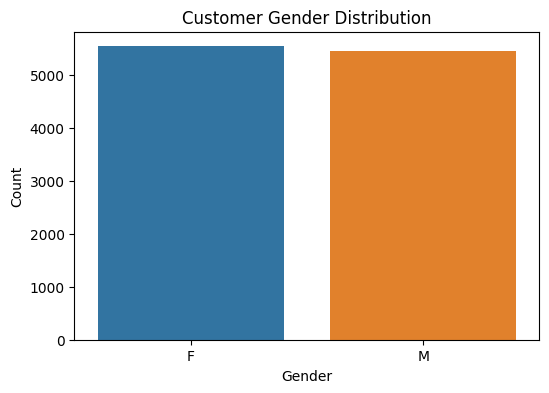

In [31]:
# Gender Distribution 
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Gender', data = df)
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Gender Distribution')

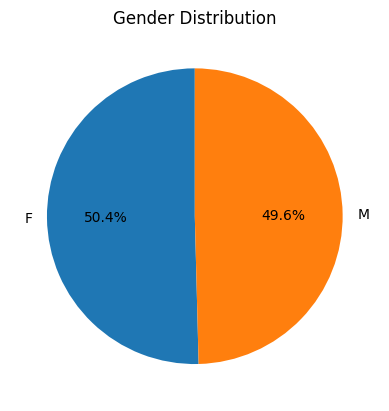

In [32]:
# Plot Pie chart for Gender Distribution
plt.pie(df['Gender'].value_counts(), labels = ['F', 'M'], autopct = '%1.1f%%', startangle = 90)
plt.title('Gender Distribution')

The dataset has the equal number of both males and female customers, with percentage of 49.6% and 50.4% respectively.

In [34]:
df.columns

Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

### Product Properties

These features describe the characteristics of the product itself, including its cost, importance, and physical attributes that may influence shipping and delivery times.

The independent features under this category include:
1. Cost_of_the_Product - Price of the product in USD. Higher-cost products may receive priority in handling or shipping.
2. Product_importance - Indicates how critical or valuable the product is (low, medium, or high).
3. Weight_in_gms - Represents the product’s weight in grams. Heavier products may take longer to ship or require special handling.

#### Weight Distribution

Text(0.5, 1.0, 'Weight Distribution')

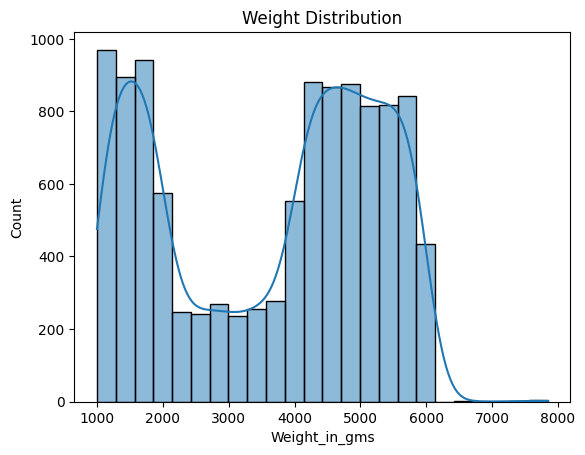

In [37]:
sns.histplot(df['Weight_in_gms'], kde = True).set_title('Weight Distribution')

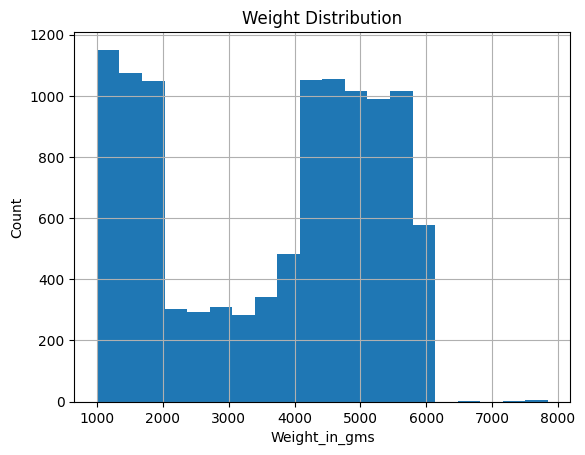

In [38]:
df['Weight_in_gms'].hist(bins = 20)
plt.title('Weight Distribution')
plt.xlabel('Weight_in_gms')
plt.ylabel('Count')
plt.show()

##### **Insight: Weight Distribution**

From the weight distribution plot, it is observed that most products weigh between 1000–2000 grams and 4000–6000 grams.
This indicates that the company primarily sells products within these weight ranges, suggesting that medium-weight and moderately heavy products dominate the inventory.

Such patterns could influence shipping mode selection and logistics planning, as heavier products may require different handling or transportation modes.

#### Product Importance

In [41]:
# Show Value Count of 'Product_importance' in the dataset
df['Product_importance'].value_counts()

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Text(0.5, 1.0, 'Product Importance')

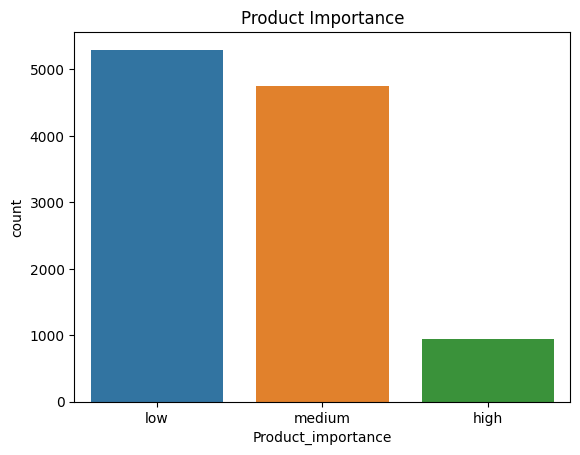

In [42]:
# Plot a bar Graph for Product_importance
sns.countplot(x = 'Product_importance', data = df).set_title('Product Importance')

##### **Insight: Product Importance**

From the data, it is evident that the majority of products are of low or medium importance, with
* Low importance: 5,297 products
* Medium importance: 4,754 products
* High importance: only 948 products

This indicates that the company mainly handles standard or less critical products, while high-importance items make up a small fraction of total shipments. Such a pattern suggests that the company’s logistics operations are primarily focused on regular inventory movement rather than urgent or high-priority deliveries

#### Cost_of_the_Product

Text(0.5, 1.0, 'Cost of the Product')

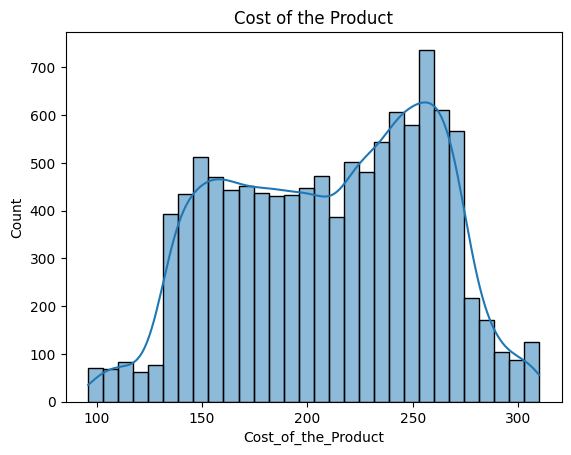

In [45]:
sns.histplot(df['Cost_of_the_Product'], kde = True).set_title('Cost of the Product')

##### **Insight: Cost of the Product**

The third graph illustrates the distribution of product costs, showing that most products are priced between $150–$200 and $225–$275.

This indicates that the company’s product portfolio is concentrated in the mid-price range, suggesting a focus on affordable to moderately priced goods rather than premium or low-cost items.

Such a pattern may also imply that customer demand is higher for mid-range products, which could be a key consideration for pricing and inventory planning.

These three graphs explain the distribution of product properties — Weight, Cost, and Importance — in the dataset.

From the analysis, it can be concluded that the majority of the products:

* Weigh less than 6000 grams,
* Have low or medium importance, and
* Are priced between 150-275 dollars.

This indicates that the company primarily deals with lightweight, moderately priced, and standard-importance products, which may influence its logistics and delivery timelines.

### Logistics and Operations

These features relate to the company’s internal operations, including warehousing and shipment processes, which directly affect delivery time and efficiency.

The independent features under this category include:

1. Warehouse_block - The warehouse section (A–E) from which the product is dispatched. Different blocks may have varying handling speeds or capacities.
2. Mode_of_Shipment - The transportation method used for delivery (Ship, Flight, or Road). Each mode affects delivery duration differently.
3. Reached.on.Time_Y.N - 

#### Warehouse Blocks

In [50]:
# Get the unique value of Warehouse Blocks
print(df['Warehouse_block'].unique())

# Get the Value Count for 'Warehouse Blocks'
df['Warehouse_block'].value_counts()

['D' 'F' 'A' 'B' 'C']


Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Text(0.5, 1.0, 'Warehouse Block')

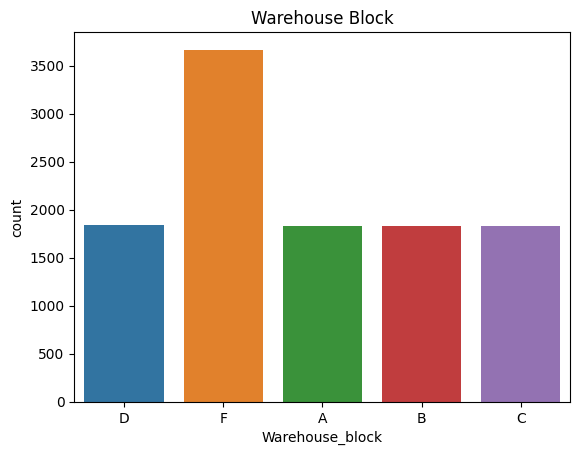

In [51]:
# Plot a bar Graph for 'Warehouse Block'
sns.countplot(x = 'Warehouse_block', data = df).set_title('Warehouse Block')

##### **Insight: Warehouse Distribution**

Warehouse F handles the largest volume of products, with 3,666 shipments, while the other warehouses (A, B, C, D) handle nearly the same number of shipments (~1,833–1,834 each). This indicates that Warehouse F may be a central or primary distribution hub, possibly dealing with a higher workload or larger capacity compared to the others.

#### Mode of Shipment

In [54]:
# Get the unique values of Mode of Shipment 
print(df['Mode_of_Shipment'].unique())

# Get a Value Count for 'Mode of Shipment'
df['Mode_of_Shipment'].value_counts()

['Flight' 'Ship' 'Road']


Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Text(0.5, 1.0, 'Mode of Shipment')

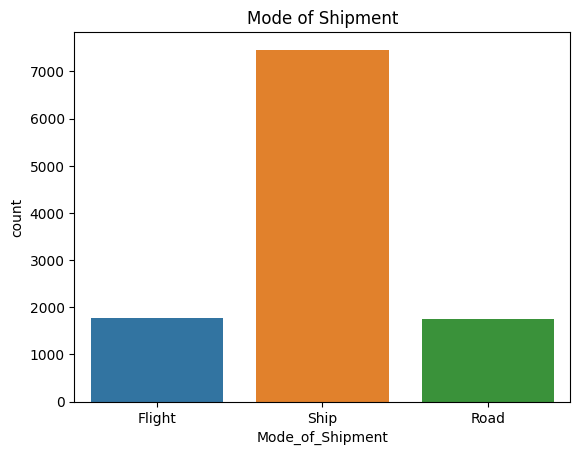

In [55]:
# Plot a bar graph for Mode of Shipment
sns.countplot(x = 'Mode_of_Shipment', data = df).set_title('Mode of Shipment')

##### **Insight: Mode of Shipment**

The majority of products are shipped via Ship (7,462 products), while nearly 1,770–1,780 products are shipped via Flight or Road. This suggests that shipping by sea is the most common mode of transportation, likely for bulk or heavy items, whereas air and road shipments are used less frequently, possibly for urgent or smaller shipments.

#### Reached.on.Time_Y.N

In [58]:
# Get the unique value of 'Reached on Time'
print(df['Reached.on.Time_Y.N'].unique())

# Get the value count for Reached on Time
df['Reached.on.Time_Y.N'].value_counts()

[1 0]


Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Text(0.5, 1.0, 'Reached on Time')

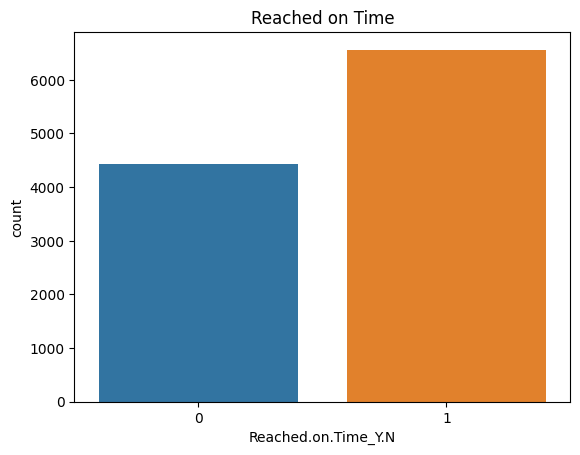

In [59]:
# PLot a bar graph for Reached on Time
sns.countplot(x = 'Reached.on.Time_Y.N', data = df).set_title('Reached on Time')

##### **Insight: Product Delivery Timeliness**

The target variable Reached.on.Time_Y.N shows that 6,563 products were not delivered on time (1) and 4,436 products were delivered on time (0). This indicates that the majority of products face delivery delays, highlighting potential challenges in the logistics and shipment process that the company may need to address.

The above three graphs visualize the logistics and delivery aspects of the products, including warehouse distribution, mode of shipment, and whether the products were delivered on time.

From these visualizations, it can be inferred that Warehouse F is likely located near a seaport, as it handles the largest number of products and the majority of shipments from this warehouse are sent via Ship. This suggests a strategic placement of the warehouse to facilitate bulk or sea-based transportation.

### Customer Experience

These features capture aspects of customer behavior, satisfaction, and interaction with the company, which can influence and reflect the overall delivery experience.

The independent features under this category include:

1. Customer_care_calls - The number of calls made by customers for shipment inquiries or complaints, indicating potential delivery issues.
2. Customer_rating - Customer satisfaction score ranging from 1 (worst) to 5 (best).
3. Prior_purchases - The number of previous purchases made by the customer, possibly indicating loyalty or prioritization in service.
4. Discount_offered - Discount percentage applied to the product, which may influence order volume and logistics demand.
5. Gender - Gender of the customer, which can be used for understanding purchase and feedback trends.

#### Customer Care Calls

In [64]:
# Get the unique value for 'Customer Care Calls'
print(df['Customer_care_calls'].unique())

# Get the value count for Customer Care Calls
df['Customer_care_calls'].value_counts()

[4 2 3 5 6 7]


Customer_care_calls
4    3557
3    3217
5    2328
6    1013
2     638
7     246
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Care Calls')

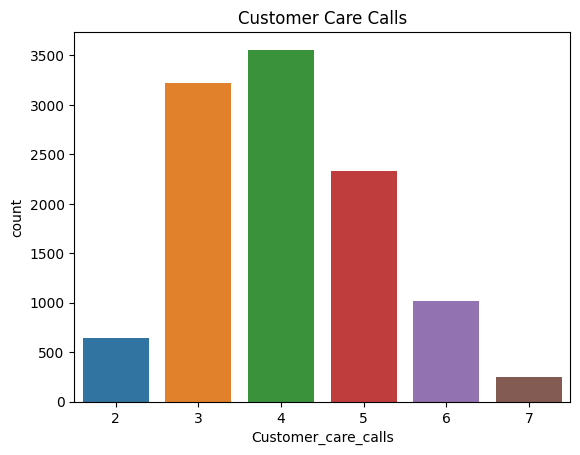

In [65]:
# Plot a bar graph for Customer_care_calls
sns.countplot(x = 'Customer_care_calls', data = df).set_title('Customer Care Calls')

##### **Insight: Customer Care Calls**

From this, we can see that most customers made 3–4 calls, indicating that they were actively tracking their deliveries. A higher number of calls may also signal potential issues or delays in product delivery, making this feature an important indicator for modeling delivery performance.

#### Customer Ratings

In [68]:
# Get the unique values for Customer Ratings
print(df['Customer_rating'].unique())

# Get the unique value for customer ratings
df['Customer_rating'].value_counts()

[2 5 3 1 4]


Customer_rating
3    2239
1    2235
4    2189
5    2171
2    2165
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Rating')

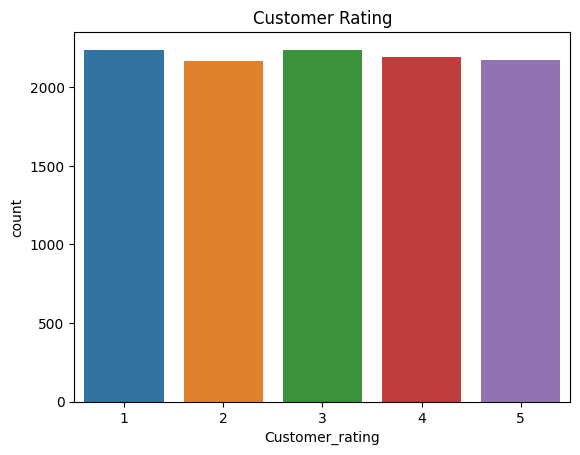

In [69]:
# Plot a graph for customer ratings
sns.countplot(x = 'Customer_rating', data = df).set_title('Customer Rating')

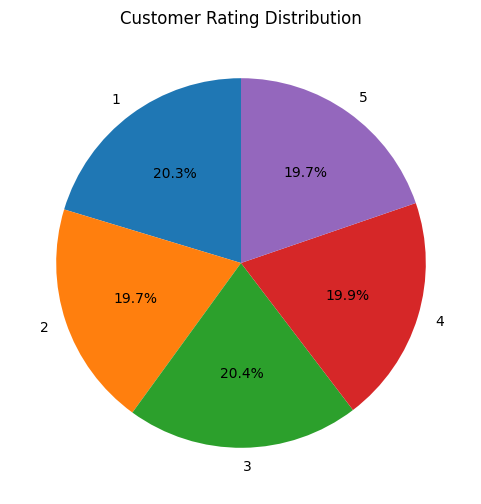

In [70]:
# Let's plot a pie chart for customer rating to see the percenatge distribution 
# Get customer rating counts sorted by rating (index)
rating_counts = df['Customer_rating'].value_counts().sort_index()  # sort by rating 1,2,3,4,5

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90
        )
plt.title('Customer Rating Distribution')
plt.show()

##### **INsight: Customer Rating**

From the counts, we observe that the ratings are relatively evenly distributed across all values. However, there is a slightly higher number of customers giving a rating of 1, which indicates that a noticeable portion of customers were not satisfied with the service.

This suggests that while many customers are moderately satisfied, service improvements may be necessary to reduce low ratings and enhance customer experience.

#### Prior Purchases

In [73]:
# Get the unique value for Prior Purchases
print(df['Prior_purchases'].unique())

# Get the value count for Prior_purchases
df['Prior_purchases'].value_counts()

[ 3  2  4  6  5  7 10  8]


Prior_purchases
3     3955
2     2599
4     2155
5     1287
6      561
10     178
7      136
8      128
Name: count, dtype: int64

Text(0.5, 1.0, 'Prior Purchases')

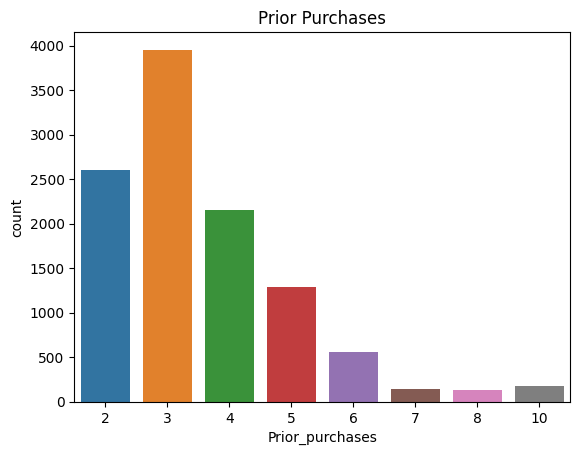

In [74]:
# Plot a graph for Prior_purchases
sns.countplot(x = 'Prior_purchases', data = df).set_title('Prior Purchases')

##### **Insight: Prior Purchases**

From the data, it is evident that the majority of customers have made 2–3 prior purchases, indicating repeat engagement. This suggests that customers with prior purchases are generally satisfied with the service and are more likely to buy additional products, reflecting loyalty and positive experience with the company.

#### Discount Offered

Text(0.5, 1.0, 'Discount Offered')

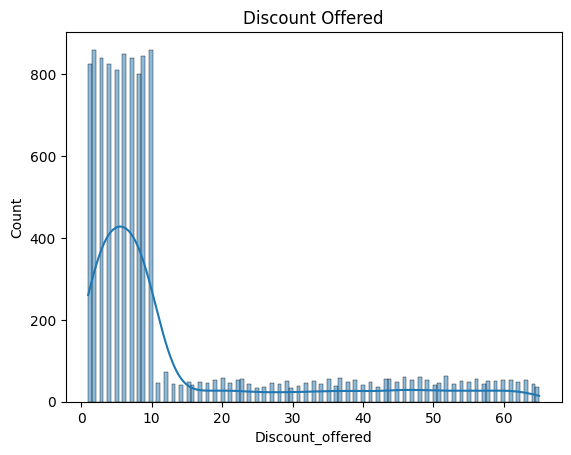

In [77]:
# Plot a graph for Discount_offered
sns.histplot(x = 'Discount_offered', data = df, kde = True).set_title('Discount Offered')

##### **Insight: Discount Offered**

The distribution of discounts on the products shows that most products have a discount in the range of 0–10%. This indicates that the company rarely offers high discounts on its products. A lower discount strategy could imply a focus on maintaining product value and revenue margins, rather than aggressively promoting sales through large discounts.

**Customer-Related Insights**

1. Customer Care Calls: Most customers make 3–4 calls regarding their orders. This indicates that a significant portion of customers are actively tracking or following up on deliveries, suggesting areas for improving delivery communication or service efficiency.

2. Customer Ratings: Ratings are fairly evenly distributed across 1–5, but slightly more customers gave a rating of 1, indicating some dissatisfaction with service. This highlights the need for enhancing customer experience.

3. Prior Purchases: A majority of customers have made 2–3 prior purchases, suggesting that repeat customers are generally satisfied with the service and continue to buy products. This is a positive signal for customer loyalty.

4. Discount Offered: Most products have 0–10% discounts, indicating that the company provides limited promotional offers. This suggests a strategy of maintaining product value rather than using discounts to drive sales.

Overall Conclusion: Customers are moderately engaged and mostly repeat buyers, but there are some service dissatisfaction signals (reflected in ratings and calls). Improving delivery reliability, customer support, and communication could further enhance satisfaction and loyalty.

#### Gender and Product Delivery

In [81]:
# Get the unique value of gender
print(df['Gender'].unique())

# Get the value count for gender
df['Gender'].value_counts()

['F' 'M']


Gender
F    5545
M    5454
Name: count, dtype: int64

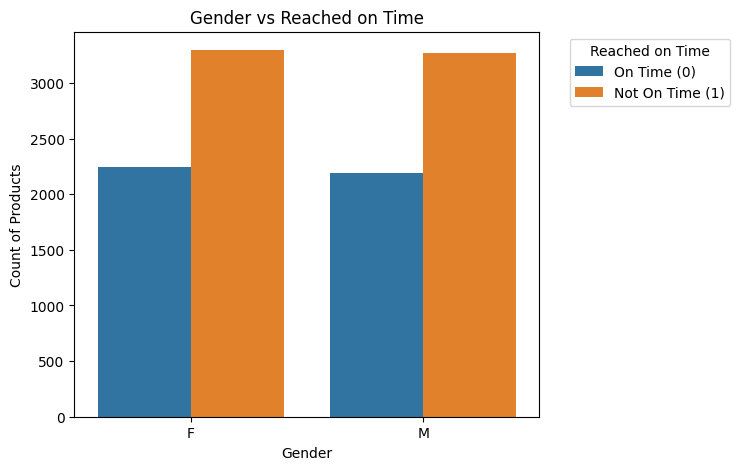

In [82]:
# Plot the graph for Gender and Target variable 
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', hue='Reached.on.Time_Y.N', data=df)
plt.title('Gender vs Reached on Time')
plt.xlabel('Gender')
plt.ylabel('Count of Products')
plt.legend(title='Reached on Time', labels=['On Time (0)', 'Not On Time (1)'],
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The number of products timely delivered for both the genders is same, which means there is no relation of customer gender and product delivery.

#### Product Properties and Product Deliveries

#### Weight Distribution vs Product Delivery

Text(0.5, 1.0, 'Weight Distribution vs Product Delivery')

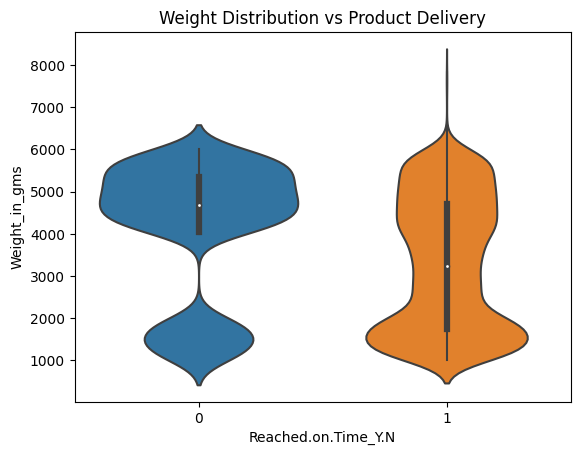

In [86]:
# Plot a Violon plot between Weight Distribution vs Product Delivery
sns.violinplot(x = 'Reached.on.Time_Y.N', y = 'Weight_in_gms', data = df).set_title('Weight Distribution vs Product Delivery')

##### **Insight: Product Weight vs Delivery Timeliness**

It is evident that product weight has a significant impact on delivery timeliness.

Products weighing more than 4,500 grams are more likely not to be delivered on time, indicating potential logistical challenges with heavier items.

Conversely, products weighing between 2,500 and 3,500 grams show a higher rate of on-time deliveries, suggesting that medium-weight products are handled more efficiently within the logistics system.

#### Product Importance vs Product Delivery

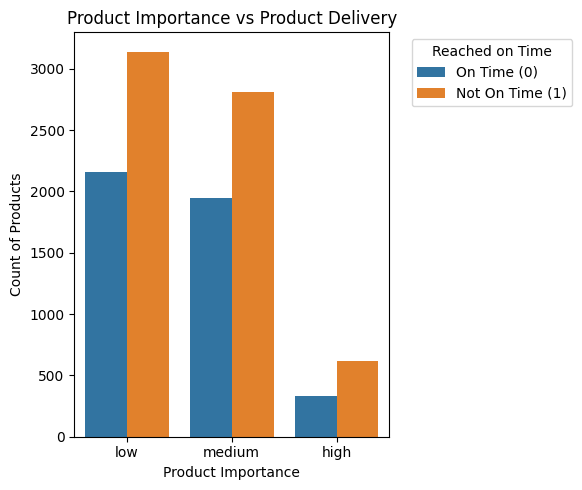

In [89]:
# Plot a graph between Product Importance vs Product Delivery
plt.figure(figsize=(6,5))
sns.countplot(x='Product_importance', hue='Reached.on.Time_Y.N', data=df)
plt.title('Product Importance vs Product Delivery')
plt.xlabel('Product Importance')
plt.ylabel('Count of Products')

# Move legend outside
plt.legend(
    title='Reached on Time',
    labels=['On Time (0)', 'Not On Time (1)'],
    bbox_to_anchor=(1.05, 1),  # moves it to the right
    loc='upper left'
)

plt.tight_layout()
plt.show()

##### **Insight: Product Importance vs Product Delivery**

From the graph, it can be observed that there is no major difference in the delivery performance across different product importance levels. Both high-, medium-, and low-importance products show a similar pattern of on-time and delayed deliveries.

This suggests that product importance does not significantly influence whether an item is delivered on time, and the company’s delivery process appears to treat all product categories with similar priority.

#### Cost of the Product vs Product Delivery

Text(0.5, 1.0, 'Cost of the Product vs Product Delivery')

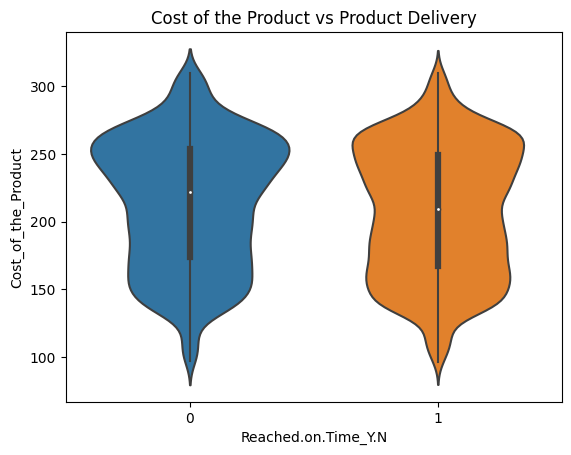

In [92]:
# Plot a Violon plot between Weight Distribution vs Product Delivery
sns.violinplot(x = 'Reached.on.Time_Y.N', y = 'Cost_of_the_Product', data = df).set_title('Cost of the Product vs Product Delivery')

##### **Insight: Cost of Product vs Product Delivery** 

The graph shows the relationship between the cost of the product and its delivery status. It can be observed that products costing more than $250 have a higher count of delayed deliveries compared to lower-cost products.

This indicates that higher-priced items may be facing logistics or handling delays, possibly due to additional quality checks, secure packaging, or transportation constraints associated with valuable products.

From the analysis, it can be concluded that product weight and cost have a significant impact on delivery performance. Heavier and higher-cost products tend to experience more delivery delays, likely due to logistics challenges, special handling requirements, or transportation constraints.

#### Logistic Operations and Product Delivery

##### Warehouse Block and Reached.on.Time_Y.N

Text(0.5, 1.0, 'Warehouse Block  vs Product Delivery')

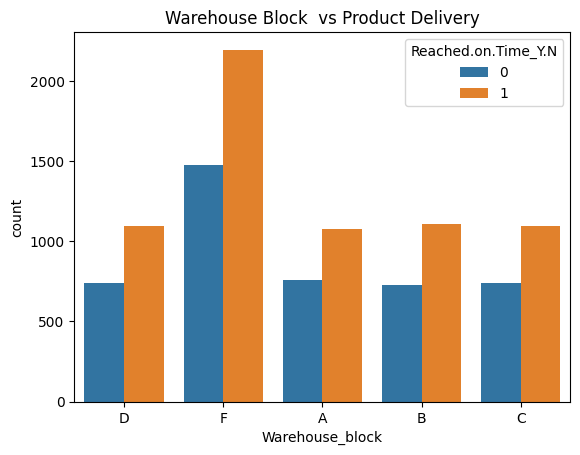

In [97]:
# Plot a graph between Warehouse Block vs Reached.on.Time_Y.N
sns.countplot(x = 'Warehouse_block', hue = 'Reached.on.Time_Y.N', data = df).set_title('Warehouse Block  vs Product Delivery')

##### **Insight: Warehouse Block**

Since most of the products are shipped from Warehouse F, it can be assumed that Warehouse F is located near a seaport, as the majority of shipments are sent via ship.

However, the difference between products delivered on time and those delayed remains relatively constant across all warehouse blocks.

This indicates that the warehouse block does not have a significant impact on product delivery performance.

##### Mode of Shipment and Reached.on.Time_Y.N

Text(0.5, 1.0, 'Mode of Shipment vs Reached.on.Time_Y.N')

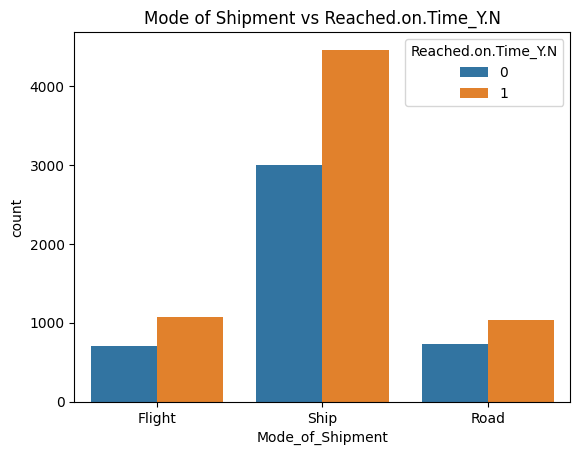

In [100]:
# Plot a graph between Mode of Shipment vs Reached.on.Time_Y.N
sns.countplot(x = 'Mode_of_Shipment', hue = 'Reached.on.Time_Y.N', data = df).set_title('Mode of Shipment vs Reached.on.Time_Y.N')

 ##### **Insight: Mode of Shipment**
 
Since most of the products are shipped from Warehouse F, it can be inferred that Warehouse F is located near a seaport, leading to a higher number of shipments made via ship.
From the graph, the difference between products delivered on time and those not delivered on time is consistent across all modes of shipment.
This suggests that the mode of shipment does not significantly impact the delivery performance.

#### Customer Experience and Product Delivery

##### Customer Care Calls and Reached.on.Time_Y.N

Text(0.5, 1.0, 'Customer_care_calls vs Reached.on.Time_Y.N')

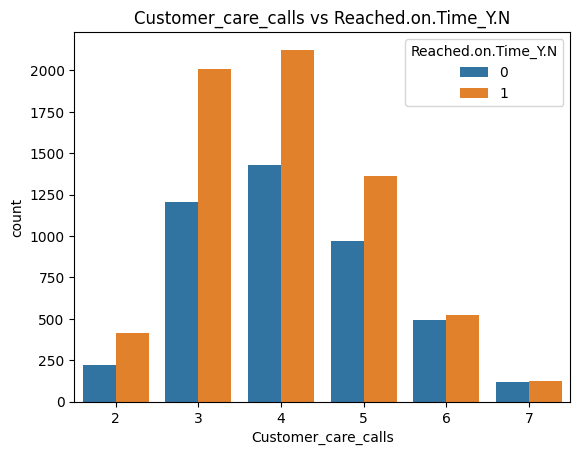

In [104]:
# Plot a graph between Customer Care Calls vs Reached.on.Time_Y.N
sns.countplot(x = 'Customer_care_calls', hue = 'Reached.on.Time_Y.N', data = df).set_title('Customer_care_calls vs Reached.on.Time_Y.N')

##### **Insight: Customer Care Calls vs Product Delivery**

From the analysis, it is observed that the difference between timely and late deliveries decreases as the number of customer care calls increases. This suggests that when product delivery is delayed, customers tend to make more calls to customer care. Hence, a higher number of customer care interactions may indicate delivery issues or customer dissatisfaction related to delayed shipments.

##### Customer Rating and Reached.on.Time_Y.N

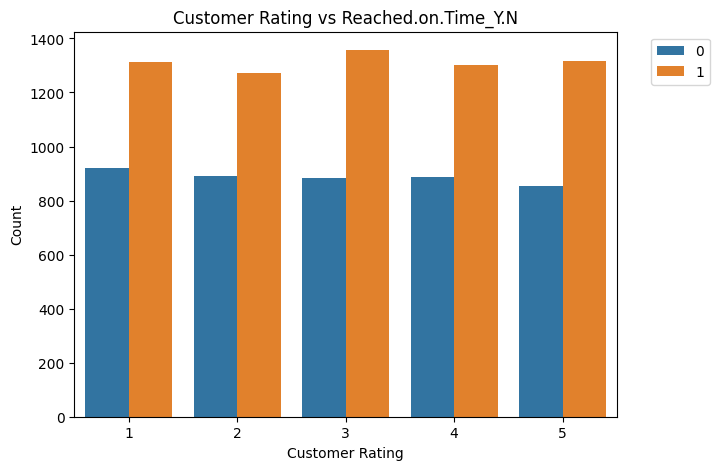

In [107]:
# PLot the graph between Customer_rating vs Reached.on.Time_Y.N
plt.figure(figsize = (7, 5))
sns.countplot(x = 'Customer_rating', hue = 'Reached.on.Time_Y.N', data = df)
plt.title('Customer Rating vs Reached.on.Time_Y.N')
plt.xlabel('Customer Rating')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc = 'upper left')
plt.show()

##### **Insight: Customer Rating vs Product Delivery**

From the analysis, it is observed that customers giving higher ratings tend to have a higher count of products delivered on time. This indicates that timely delivery positively influences customer satisfaction, as customers who receive their products on time are more likely to provide better ratings.

##### Prior Purchases and Reached.on.Time_Y.N

Text(0.5, 1.0, 'Prior Purchases vs Reached.on.Time_Y.N')

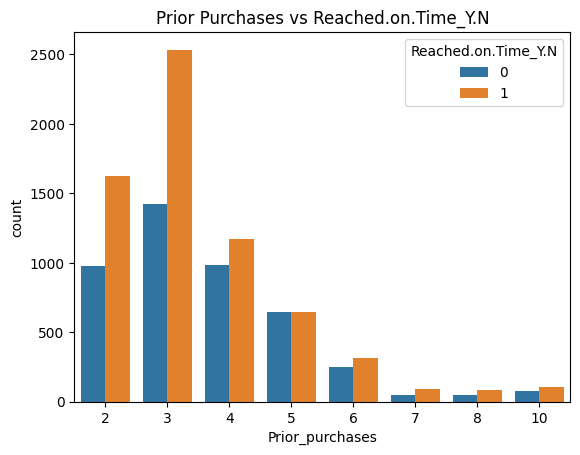

In [110]:
# plot a graph between Prior Purchases vs Reached.on.Time_Y.N
sns.countplot(x = 'Prior_purchases', hue = 'Reached.on.Time_Y.N', data = df).set_title('Prior Purchases vs Reached.on.Time_Y.N')

##### **Insight: Prior Purchases vs Product Delivery**

The analysis shows that customers with a higher number of prior purchases tend to have more products delivered on time. This indicates that timely delivery and positive past experiences encourage customers to make repeat purchases from the company.

##### Discount Offered and Reached.on.Time_Y.N

Text(0.5, 1.0, 'Discount Offered vs Product Delivered')

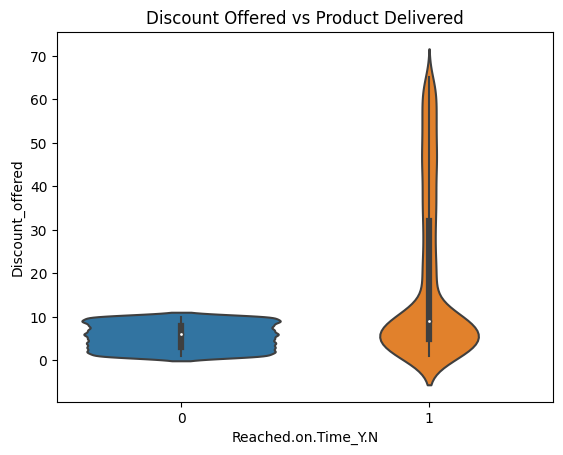

In [113]:
# Plot a Graph Between Discount Offered vs Product Delivered
sns.violinplot(y = 'Discount_offered', x = 'Reached.on.Time_Y.N', data = df).set_title('Discount Offered vs Product Delivered')

##### **Insight: Discount Offered vs Product Delivery**

The analysis reveals that products with a 0–10% discount tend to have a higher count of late deliveries, whereas products with discounts above 10% show a higher count of on-time deliveries. This may indicate that discounted products are managed more efficiently or prioritized for timely delivery to maintain customer satisfaction and encourage future purchases.

It is important to understand the customer experience and respond to services provided by the E-Commerce company. The above graphs explain the relationship between customer experience and product delivery. The first graph is about the customer care calls and product delivery, where we that the difference in timely and late delivery of the product decreases with increase in the number of calls by the customer, which means that with the delay in product delivery the customer gets anxious about the product and calls the customer care. The second graph is about the customer rating and product delivery, where we can see that customers who  rating have higher count of products delivered on time.

The third graph is about the customer's prior purchase, which also shows that customers who have done more prior purchases have higher count of products delivered on time and this is the reason that they are purchasing again from the company. The fourth graph is about the discount offered on the product and product delivery, where we can see that products that have 0-10% discount have higher count of products delivered late, whereas products that have discount more than 10% have higher count of products delivered on time.

#### Identifying Categorical Variables

In [117]:
# Indentify Categorical Variables
categorical_vars = [col for col in df.columns if df[col].dtype in ['object']]
num_categorical_vars = len(categorical_vars)
print(f"Count of Categorical Variables in the dataset: {num_categorical_vars}")
print(f"Categorical Variables in the dataset are: {categorical_vars}")

Count of Categorical Variables in the dataset: 4
Categorical Variables in the dataset are: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


### Converting Categorical Variables to Numerical Variables

### Label Encoding the Categorical Variables

In [120]:
# Import Label Encoding function
from sklearn.preprocessing import LabelEncoder

# Create Label Encoding Object
le = LabelEncoder()
le

LabelEncoder()

In [121]:
# # Create a dictionary to store encoders and their mappings
label_mappings = {}

# List of categorical columns
cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

# Apply Label Encoding and store mappings
for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display mappings
for col, mapping in label_mappings.items():
    print(f"\n{col} Mapping:")
    for category, code in mapping.items():
        print(f"  {category} → {code}")


Warehouse_block Mapping:
  A → 0
  B → 1
  C → 2
  D → 3
  F → 4

Mode_of_Shipment Mapping:
  Flight → 0
  Road → 1
  Ship → 2

Product_importance Mapping:
  high → 0
  low → 1
  medium → 2

Gender Mapping:
  F → 0
  M → 1


### Corrleation Matrix

<Axes: >

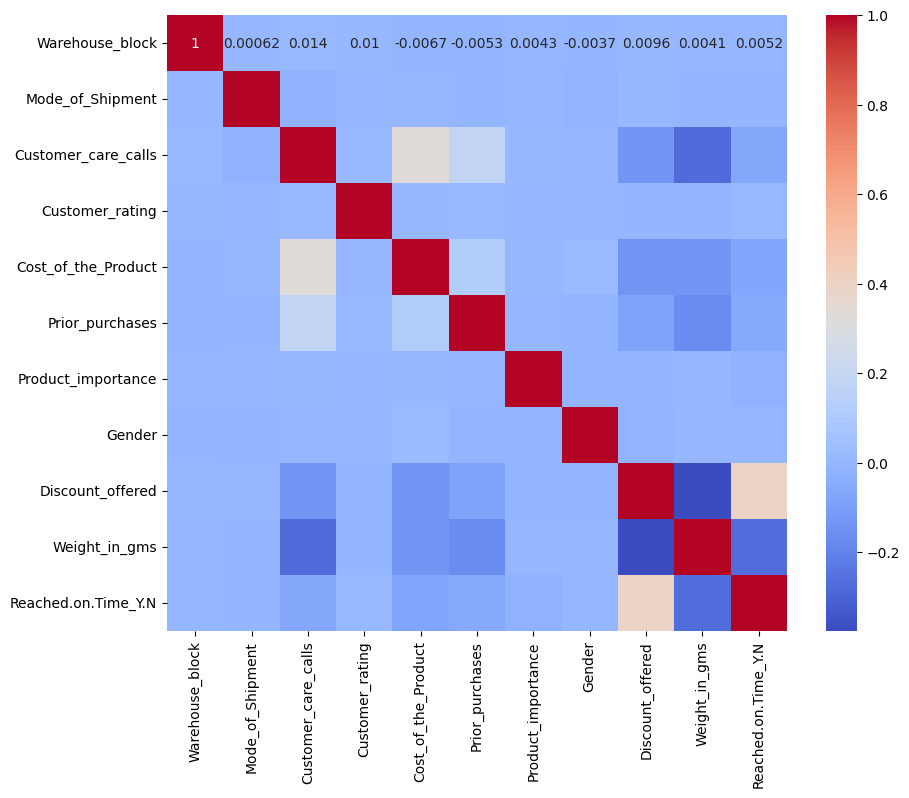

In [123]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

In the correlation matrix heatmap, we can see that there is positive correlation between cost of product and number of customer care calls.

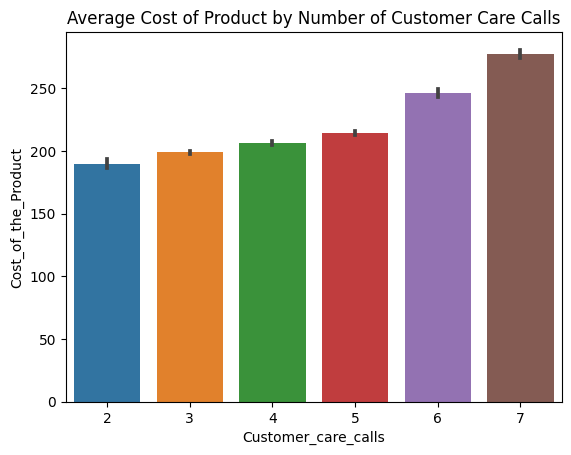

In [125]:
sns.barplot(x = 'Customer_care_calls', y = 'Cost_of_the_Product', data = df).set_title('Cutomer Care Calls vs Cost of the Product')
plt.title('Average Cost of Product by Number of Customer Care Calls')
plt.show()

It is clear that customer are more concern regarding the delivery of the product when the cost of the product is high. This is the reason that they call the customer care to know the status of the product. So, it is important to make sure the delivery of the product is on time when the cost of the product is high.

### Train Test Split

In [128]:
# Import Train Test Split library function
from sklearn.model_selection import train_test_split

In [129]:
# Assigning Independent Variable (X) and Dependent Variable (y)
X = df.drop(['Reached.on.Time_Y.N'], axis = 1)
y = df['Reached.on.Time_Y.N']

In [130]:
# Apply Train Test Split function 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [131]:
# Shape of Train and test dataset
print("X Train: ", X_train.shape)
print("y Train: ", y_train.shape)
print("X Test: ", X_test.shape)
print("y Test: ", y_test.shape)

X Train:  (7699, 10)
y Train:  (7699,)
X Test:  (3300, 10)
y Test:  (3300,)


### Standardization

In [133]:
# Import library for Standardization
from sklearn.preprocessing import StandardScaler

In [134]:
# Standardization Object
scaler = StandardScaler()
scaler

StandardScaler()

In [135]:
# Standardizing our traning data
# First will fit and transform into training dataset and later will only transform into testing dataset.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Building

I will be using the following models to predict the product delivery:

- Random Forest Classifier
- Decision Tree Classifier
- Logistic Regression
- K Nearest Neighbors

### Random Forest Classifier

In [138]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Random Forest Object
rfc = RandomForestClassifier()
rfc

RandomForestClassifier()

In [139]:
# Fit the model
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [140]:
# Predicting on the test data
y_pred = rfc.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [141]:
### Model Evaluation for Random Forest Classifier
print('Predicted Values: ', y_pred[:10])
print('Actual Values: ', y_test[:10])

Predicted Values:  [0 1 0 1 0 1 1 0 0 0]
Actual Values:  7030    0
2095    1
7168    1
7969    0
6320    1
6136    0
4687    1
9934    1
7868    0
4865    0
Name: Reached.on.Time_Y.N, dtype: int64


In [142]:
# Accuracy score
print('Accuracy:', rfc.score(X_test,y_test))

Accuracy: 0.6554545454545454


#### Hyperparameter Tuining - Random Forest Classifier

In [144]:
# Using GridSearch for hyperparameter tuining
# Import GridSearchCV 
from sklearn.model_selection import GridSearchCV

In [145]:
# Grid parameters
param_grid = {'max_depth': [4, 8, 12, 16],
                  'min_samples_leaf': [2, 4, 6, 8],
                  'min_samples_split': [2, 4, 6, 8],
                  'criterion': ['gini', 'entropy'],
                  'random_state': [0, 42]
}

# GridSearchCV Object
grid = GridSearchCV(estimator = rfc, param_grid = param_grid, cv = 5, n_jobs = -1, verbose = 2, scoring = 'accuracy')
grid

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 8, 12, 16],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [2, 4, 6, 8],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=2)

In [146]:
# Fitting the model
grid.fit(X_train, y_train)

# Best parameters
print('Best Parameters: ' , grid.best_params_)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best Parameters:  {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'random_state': 0}


In [147]:
# Random Forest Classifier Object
rfc = RandomForestClassifier(criterion = 'gini', max_depth = 4, min_samples_leaf = 2,
                             min_samples_split = 2, random_state = 0)

# Fitting the model
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=2, random_state=0)

In [148]:
# Training Accuracy
print('Training Accuracy: ', rfc.score(X_train, y_train))
print('Test Accuracy:', rfc.score(X_test, y_test))

Training Accuracy:  0.6887907520457203
Test Accuracy: 0.69


In [192]:
# Predicting the test set results
rfc_pred = rfc.predict(X_test)
rfc_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

### Decision Tree Classifier

In [195]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dtc = DecisionTreeClassifier()
dtc

DecisionTreeClassifier()

In [197]:
# Train the base model
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [199]:
# Predict the diagnosis
y_pred = dtc.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [201]:
# Printing Samples from Predicted and Actual Values
print('Predicted Values: ', y_pred[:10])
print('\nActual Values: ', y_test[:10])

Predicted Values:  [0 1 0 1 0 0 1 1 0 0]

Actual Values:  7030    0
2095    1
7168    1
7969    0
6320    1
6136    0
4687    1
9934    1
7868    0
4865    0
Name: Reached.on.Time_Y.N, dtype: int64


In [203]:
# Model Evalution 
print(dtc.score(X_test, y_test))

0.6396969696969697


### Decision Tree Classifier - Uisng GridSearchCV Hyperparameter Tuining

In [206]:
parameter_grid = {'max_depth': [2, 4, 6, 8],
                  'min_samples_leaf': [2, 4, 6, 8],
                  'min_samples_split': [2, 4, 6, 8],
                  'criterion': ['gini', 'entropy'],
                  'random_state': [0, 42]
                                }

In [208]:
# GridSearchCV Object
grid = GridSearchCV(estimator = dtc, param_grid = parameter_grid,
                    cv = 5, n_jobs = -1, verbose = 2, scoring = 'accuracy')
grid

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [2, 4, 6, 8],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=2)

In [210]:
# Fitting The model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [2, 4, 6, 8],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=2)

In [211]:
# Best parameters
print('Best Parameters for Decision Tree Classifier Using GridSearchCV Hyperparameter: ', grid.best_params_)

Best Parameters for Decision Tree Classifier Using GridSearchCV Hyperparameter:  {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'random_state': 0}


In [212]:
# Decision Tree Classifier Implementation using Hyperparameters 
dtc = DecisionTreeClassifier(criterion = 'entropy', max_depth = 4, min_samples_leaf = 2,
                             min_samples_split = 2, random_state = 0)
dtc

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=2,
                       random_state=0)

In [213]:
# Fitting the model
dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=2,
                       random_state=0)

In [214]:
# Training accuracy
dtc.score(X_train, y_train)

0.6845044811014418

In [233]:
# Predicting the test results
dtc_pred = dtc.predict(X_test)
dtc_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

## Logistic Regression

In [217]:
# Import Logistic Regression library
from sklearn.linear_model import LogisticRegression

# Logistic Regression object
lr = LogisticRegression()
lr

LogisticRegression()

In [218]:
# Fitting the model
lr.fit(X_train, y_train)

LogisticRegression()

In [219]:
# Training Accuracy
lr.score(X_train, y_train)

0.6408624496687881

In [220]:
# predicting the test set results
lr_pred = lr.predict(X_test)
lr_pred 

array([0, 1, 0, ..., 1, 0, 0], dtype=int64)

## K Nearest Neighbors

In [222]:
# Import Logistic Regression library
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression object
knn = KNeighborsClassifier()
knn

KNeighborsClassifier()

In [223]:
# Fitting the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [224]:
# Training Accuracy
knn.score(X_train, y_train)

0.7799714248603715

In [225]:
# predicting the test set results
knn_pred = knn.predict(X_test)
knn_pred 

array([0, 1, 1, ..., 0, 0, 0], dtype=int64)

## Model Evaluation

In [227]:
# Import libraries for model evalution
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, r2_score, mean_squared_error

Text(0.5, 1.0, 'KNNClassiifer')

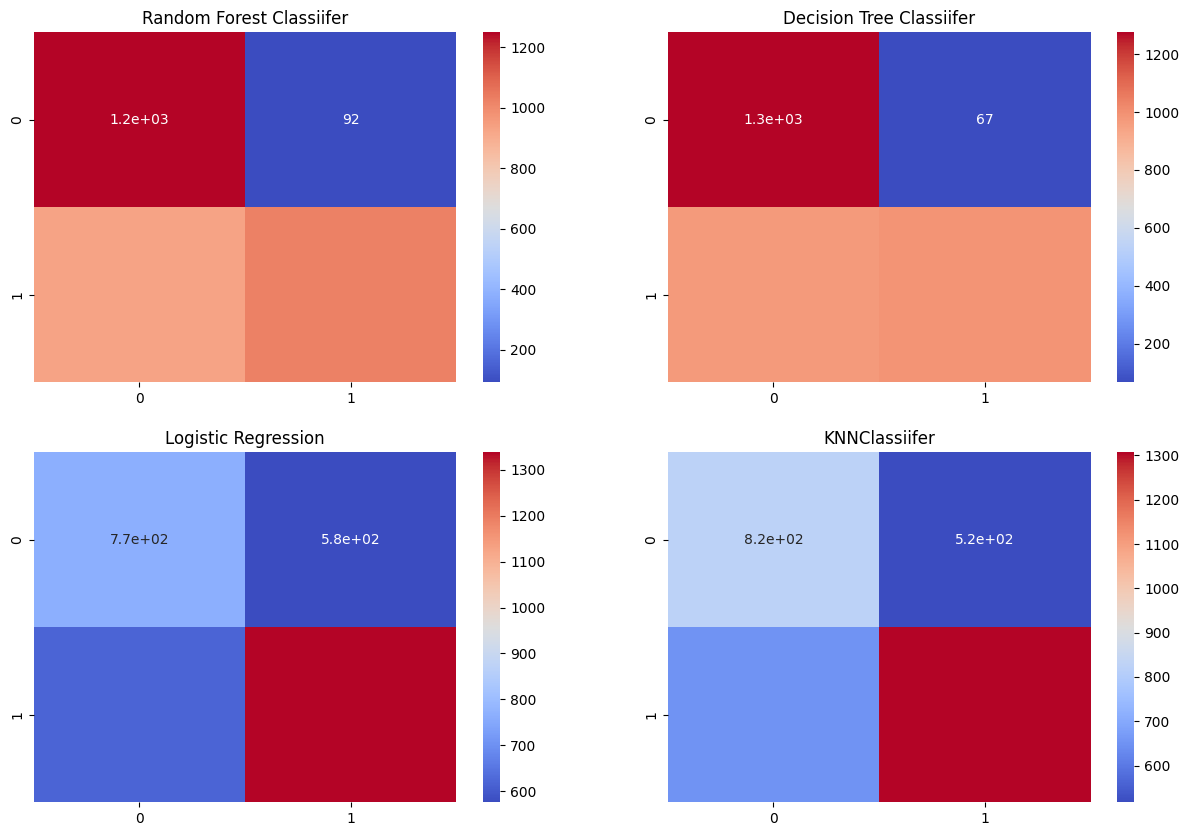

In [235]:
# Plot graph 
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
sns.heatmap(confusion_matrix(y_test, rfc_pred), annot = True, cmap = 'coolwarm', ax = ax[0,0]).set_title('Random Forest Classiifer')
sns.heatmap(confusion_matrix(y_test, dtc_pred), annot = True, cmap = 'coolwarm', ax = ax[0,1]).set_title('Decision Tree Classiifer')
sns.heatmap(confusion_matrix(y_test, lr_pred), annot = True, cmap = 'coolwarm', ax = ax[1,0]).set_title('Logistic Regression')
sns.heatmap(confusion_matrix(y_test, knn_pred), annot = True, cmap = 'coolwarm', ax = ax[1,1]).set_title('KNNClassiifer')

In [239]:
# Classification Report
print('Random Forest Classifier: \n', classification_report(y_test, rfc_pred))
print('Decision Tree Classifier: \n', classification_report(y_test, dtc_pred))
print('Logistic Regression: \n', classification_report(y_test, lr_pred))
print('KNN Classifier: \n', classification_report(y_test, knn_pred))

Random Forest Classifier: 
               precision    recall  f1-score   support

           0       0.57      0.93      0.71      1342
           1       0.92      0.52      0.67      1958

    accuracy                           0.69      3300
   macro avg       0.75      0.73      0.69      3300
weighted avg       0.78      0.69      0.68      3300

Decision Tree Classifier: 
               precision    recall  f1-score   support

           0       0.57      0.95      0.71      1342
           1       0.94      0.51      0.66      1958

    accuracy                           0.69      3300
   macro avg       0.75      0.73      0.68      3300
weighted avg       0.79      0.69      0.68      3300

Logistic Regression: 
               precision    recall  f1-score   support

           0       0.55      0.57      0.56      1342
           1       0.70      0.68      0.69      1958

    accuracy                           0.64      3300
   macro avg       0.63      0.63      0.63      

### Model Comparison

Text(0, 0.5, 'Accuracy')

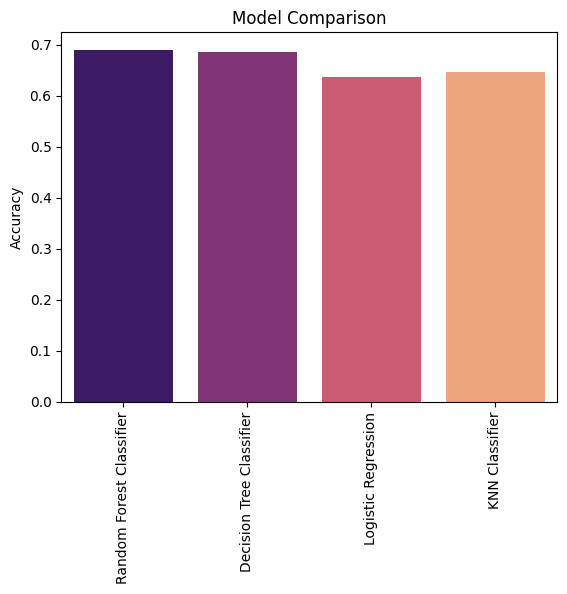

In [242]:
models = ['Random Forest Classifier', 'Decision Tree Classifier', 'Logistic Regression', 'KNN Classifier']
accuracy = [accuracy_score(y_test, rfc_pred), accuracy_score(y_test, dtc_pred),
            accuracy_score(y_test, lr_pred), accuracy_score(y_test, knn_pred)]
sns.barplot(x = models, y = accuracy, palette = 'magma').set_title('Model Comparison')
plt.xticks(rotation = 90)
plt.ylabel('Accuracy')

### Conclusion 

The aim of the project was to predict whether the product from an e-commerce company will reach on time or not. This project also analyzes various factors that affect the delivery of the product as well as studies the customer behavior. From the exploratory data analysis, I found that the product weight and cost has an impact on the product delivery. Where product that weighs between 2500 - 3500 grams and having cost less than 250 dollars had higher rate of being delivered on time. Most of the products were shipped from warehouse F though ship, so it is quite possible that warehouse F is close to a seaport. 

The customer's behaviour also help in predicting the timely delivery of the product. The more the customer calls, higher the chances the product delivery is delayed. Interestingly, the customers who have done more prior purchases have higher count of products delivered on time and this is the reason that they are purchasing again from the company. The products that have 0-10% discount have higher count of products delivered late, whereas products that have discount more than 10% have higher count of products delivered on time.
 
Coming to the machine learning models, the decision tree classifier as the highest accuracy among the other models, with accuracy of 69%. The random forest classifier and logistic regression had accuracy of 68% and 67% respectively. The K Nearest Neighbors had the lowest accuracy of 65%.